In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Veri
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),   # Data augmentation!
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=128, shuffle=False)

print(f"Train: {len(train_data)} örnek")
print(f"Test:  {len(test_data)} örnek")
print("\nSenin mimarini yazmaya hazır!")

C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000 örnek
Test:  10000 örnek

Senin mimarini yazmaya hazır!


In [6]:
class BenimModelim(nn.Module):
    def __init__(self):
        super().__init__()

            

        # Conv katmanları
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)  
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1) 
        self.bn4 = nn.BatchNorm2d(64)

        # FC katmanları
        self.fc1 = nn.Linear(64 * 4 * 4, 256)  # Örnek: 64 filtre, 8x8 feature map
        self.fc2 = nn.Linear(256, 10)  # CIFAR-10 için 10 sınıf
        self.dropout = nn.Dropout(0.3)

        pass

    def forward(self, x):

        # Conv katmanları
        x1 = torch.relu(self.bn1(self.conv1(x)))  # 32 filtre
        x2 = torch.relu(self.bn2(self.conv2(x1)))  # 64 filtre
        x3 = torch.relu(self.bn3(self.conv3(x2)))  # 128 filtre
        x4 = torch.relu(self.bn4(self.conv4(x3)))  # 128 filtre 
        x4 = torch.max_pool2d(x4, 2) 
        x4 = torch.max_pool2d(x4, 2) # 8x8 feature map
        x4 = torch.max_pool2d(x4, 2) # 8x8 feature map
        x4 = self.dropout(x4)
        x4 = x4.view(x4.size(0), -1)  # Flatten
        x5 = torch.relu(self.fc1(x4))  # 256 nöron
        x5 = self.dropout(x5)
        out = self.fc2(x5)  # 10 sınıf
        

        return out

# Modeli test et
model = BenimModelim()
x_test = torch.randn(4, 3, 32, 32)
out = model(x_test)
print("Çıktı shape:", out.shape)  # (4, 10) olmalı

toplam_param = sum(p.numel() for p in model.parameters())
print(f"Toplam parametre: {toplam_param:,}")
print(f"500K sınırı: {'✅ Geçti!' if toplam_param < 500000 else '❌ Çok fazla!'}")

Çıktı shape: torch.Size([4, 10])
Toplam parametre: 358,666
500K sınırı: ✅ Geçti!


In [8]:
# Daha küçük subset ile hızlı test
train_subset = torch.utils.data.Subset(train_data, range(10000))
test_subset = torch.utils.data.Subset(test_data, range(2000))

train_loader_hizli = torch.utils.data.DataLoader(
    train_subset, batch_size=128, shuffle=True)
test_loader_hizli = torch.utils.data.DataLoader(
    test_subset, batch_size=128, shuffle=False)

def train_model_hizli(model, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    criterion = nn.CrossEntropyLoss()

    train_accs, test_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct = 0
        for X, y in train_loader_hizli:
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            correct += (out.argmax(1) == y).sum().item()

        train_acc = correct / len(train_subset)

        model.eval()
        correct = 0
        with torch.no_grad():
            for X, y in test_loader_hizli:
                out = model(X)
                correct += (out.argmax(1) == y).sum().item()

        test_acc = correct / len(test_subset)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        scheduler.step()

        print(f"Epoch {epoch+1:2d}/{epochs} | Train: {train_acc:.2%} | Test: {test_acc:.2%}")

    return train_accs, test_accs

model = BenimModelim()
print("Eğitim başlıyor — 10 epoch, 10K örnek...")
train_accs, test_accs = train_model_hizli(model)
print(f"\nSon test accuracy: {test_accs[-1]:.2%}")
print(f"Hedef: %70 → {'✅ Başardın!' if test_accs[-1] > 0.70 else '❌ Henüz değil!'}")

Eğitim başlıyor — 10 epoch, 10K örnek...
Epoch  1/10 | Train: 26.03% | Test: 32.40%
Epoch  2/10 | Train: 36.92% | Test: 40.95%
Epoch  3/10 | Train: 41.65% | Test: 47.25%
Epoch  4/10 | Train: 45.41% | Test: 52.15%
Epoch  5/10 | Train: 47.07% | Test: 51.75%
Epoch  6/10 | Train: 49.45% | Test: 57.60%
Epoch  7/10 | Train: 52.11% | Test: 54.20%
Epoch  8/10 | Train: 53.73% | Test: 59.90%
Epoch  9/10 | Train: 55.53% | Test: 60.40%
Epoch 10/10 | Train: 55.96% | Test: 60.35%

Son test accuracy: 60.35%
Hedef: %70 → ❌ Henüz değil!


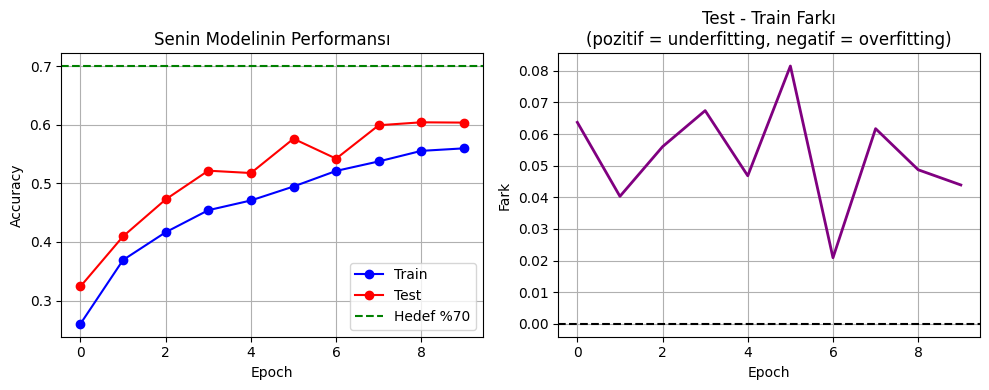

Analiz:
Son train: 55.96%
Son test:  60.35%
Fark:      +4.39%

→ Underfitting var — model daha fazla öğrenebilir
  Çözüm: Daha fazla epoch veya daha büyük model


In [9]:
# Mevcut sonucu görselleştir
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_accs, 'b-o', label='Train')
plt.plot(test_accs, 'r-o', label='Test')
plt.axhline(y=0.70, color='green', linestyle='--', label='Hedef %70')
plt.title("Senin Modelinin Performansı")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
fark = [t - tr for t, tr in zip(test_accs, train_accs)]
plt.plot(fark, 'purple', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Test - Train Farkı\n(pozitif = underfitting, negatif = overfitting)")
plt.xlabel("Epoch")
plt.ylabel("Fark")
plt.grid(True)

plt.tight_layout()
plt.show()

print("Analiz:")
print(f"Son train: {train_accs[-1]:.2%}")
print(f"Son test:  {test_accs[-1]:.2%}")
print(f"Fark:      {test_accs[-1]-train_accs[-1]:+.2%}")

if test_accs[-1] > train_accs[-1]:
    print("\n→ Underfitting var — model daha fazla öğrenebilir")
    print("  Çözüm: Daha fazla epoch veya daha büyük model")
else:
    print("\n→ Overfitting var — model ezberliyor")
    print("  Çözüm: Dropout artır veya veri artırımı")

In [10]:
# V2 — Daha uzun eğitim (20 epoch)
print("=== V2: Daha uzun eğitim ===")
model_v2 = BenimModelim()
train_accs_v2, test_accs_v2 = train_model_hizli(model_v2, epochs=20)
print(f"V2 son test: {test_accs_v2[-1]:.2%}\n")

# V3 — Dropout azalt (0.3 → 0.1)
class BenimModelimV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.fc1 = nn.Linear(64 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.1)  # 0.3 → 0.1

    def forward(self, x):
        x1 = torch.relu(self.bn1(self.conv1(x)))
        x2 = torch.relu(self.bn2(self.conv2(x1)))
        x2 = torch.max_pool2d(x2, 2)
        x3 = torch.relu(self.bn3(self.conv3(x2)))
        x4 = torch.relu(self.bn4(self.conv4(x3)))
        x4 = x4 + x3
        x4 = torch.max_pool2d(x4, 2)
        x4 = torch.max_pool2d(x4, 2)
        x4 = x4.view(x4.size(0), -1)
        x4 = self.dropout(torch.relu(self.fc1(x4)))
        return self.fc2(x4)

print("=== V3: Dropout azaltıldı (0.1) ===")
model_v3 = BenimModelimV3()
train_accs_v3, test_accs_v3 = train_model_hizli(model_v3, epochs=20)
print(f"V3 son test: {test_accs_v3[-1]:.2%}\n")

# V4 — Learning rate artır
print("=== V4: SGD + Momentum ===")
def train_model_sgd(model, epochs=20):
    optimizer = torch.optim.SGD(model.parameters(),
                                lr=0.1, momentum=0.9,
                                weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    criterion = nn.CrossEntropyLoss()
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct = 0
        for X, y in train_loader_hizli:
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            correct += (out.argmax(1) == y).sum().item()
        train_acc = correct / len(train_subset)

        model.eval()
        correct = 0
        with torch.no_grad():
            for X, y in test_loader_hizli:
                correct += (model(X).argmax(1) == y).sum().item()
        test_acc = correct / len(test_subset)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        scheduler.step()

        if (epoch+1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Test: {test_acc:.2%}")

    return train_accs, test_accs

model_v4 = BenimModelimV3()

train_accs_v4, test_accs_v4 = train_model_sgd(model_v4)
print(f"V4 son test: {test_accs_v4[-1]:.2%}")

=== V2: Daha uzun eğitim ===
Epoch  1/20 | Train: 25.62% | Test: 39.15%
Epoch  2/20 | Train: 37.13% | Test: 45.60%
Epoch  3/20 | Train: 42.34% | Test: 49.65%
Epoch  4/20 | Train: 46.13% | Test: 51.40%
Epoch  5/20 | Train: 48.45% | Test: 54.10%
Epoch  6/20 | Train: 50.53% | Test: 55.20%
Epoch  7/20 | Train: 53.34% | Test: 59.30%
Epoch  8/20 | Train: 54.20% | Test: 60.25%
Epoch  9/20 | Train: 56.02% | Test: 61.70%
Epoch 10/20 | Train: 57.23% | Test: 62.35%
Epoch 11/20 | Train: 58.10% | Test: 63.70%
Epoch 12/20 | Train: 59.22% | Test: 64.40%
Epoch 13/20 | Train: 60.40% | Test: 65.55%
Epoch 14/20 | Train: 62.08% | Test: 65.15%
Epoch 15/20 | Train: 62.48% | Test: 65.25%
Epoch 16/20 | Train: 63.43% | Test: 66.95%
Epoch 17/20 | Train: 63.31% | Test: 68.00%
Epoch 18/20 | Train: 63.86% | Test: 67.70%
Epoch 19/20 | Train: 63.77% | Test: 68.15%
Epoch 20/20 | Train: 64.73% | Test: 67.85%
V2 son test: 67.85%

=== V3: Dropout azaltıldı (0.1) ===
Epoch  1/20 | Train: 29.40% | Test: 40.75%
Epoch  2/20

C:\Users\PC\AppData\Local\Temp\ipykernel_28328\4276988926.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


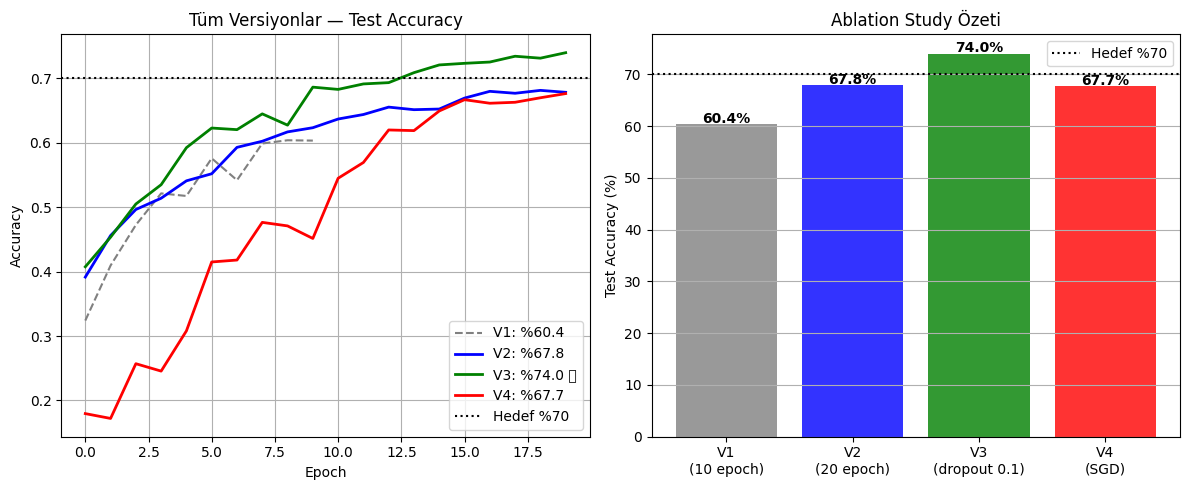

ABLATION STUDY SONUÇLARI
V1 — Temel model (10 epoch):     60.35%
V2 — Daha uzun eğitim (20 ep):   67.85%
V3 — Dropout 0.1 (20 ep):        74.00% ✅ KAZANAN!
V4 — SGD + Momentum:             67.65%

En önemli karar: Dropout 0.3→0.1
Katkısı: +6.2% (V2 ile karşılaştırıldığında)

Neden? Underfitting vardı — model öğrenemiyordu
Dropout azaltınca model daha özgür öğrendi!


In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(test_accs, 'gray', linewidth=1.5, linestyle='--', label=f'V1: %{test_accs[-1]*100:.1f}')
plt.plot(test_accs_v2, 'blue', linewidth=2, label=f'V2: %{test_accs_v2[-1]*100:.1f}')
plt.plot(test_accs_v3, 'green', linewidth=2, label=f'V3: %{test_accs_v3[-1]*100:.1f} ✅')
plt.plot(test_accs_v4, 'red', linewidth=2, label=f'V4: %{test_accs_v4[-1]*100:.1f}')
plt.axhline(y=0.70, color='black', linestyle=':', label='Hedef %70')
plt.title("Tüm Versiyonlar — Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
versiyonlar = ['V1\n(10 epoch)', 'V2\n(20 epoch)', 'V3\n(dropout 0.1)', 'V4\n(SGD)']
sonuç_değerleri = [test_accs[-1]*100, test_accs_v2[-1]*100,
                   test_accs_v3[-1]*100, test_accs_v4[-1]*100]
renkler = ['gray', 'blue', 'green', 'red']
bars = plt.bar(versiyonlar, sonuç_değerleri, color=renkler, alpha=0.8)
plt.axhline(y=70, color='black', linestyle=':', label='Hedef %70')
plt.title("Ablation Study Özeti")
plt.ylabel("Test Accuracy (%)")
plt.legend()
plt.grid(True, axis='y')
for bar, val in zip(bars, sonuç_değerleri):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("=" * 45)
print("ABLATION STUDY SONUÇLARI")
print("=" * 45)
print(f"V1 — Temel model (10 epoch):     {test_accs[-1]:.2%}")
print(f"V2 — Daha uzun eğitim (20 ep):   {test_accs_v2[-1]:.2%}")
print(f"V3 — Dropout 0.1 (20 ep):        {test_accs_v3[-1]:.2%} ✅ KAZANAN!")
print(f"V4 — SGD + Momentum:             {test_accs_v4[-1]:.2%}")
print()
print("En önemli karar: Dropout 0.3→0.1")
print(f"Katkısı: +{(test_accs_v3[-1]-test_accs_v2[-1])*100:.1f}% (V2 ile karşılaştırıldığında)")
print()
print("Neden? Underfitting vardı — model öğrenemiyordu")
print("Dropout azaltınca model daha özgür öğrendi!")